In [1]:
import pandas as pd
import numpy as np 
import statistics as st
from sklearn.preprocessing import StandardScaler as ss
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
dat = pd.read_csv(r"E:\DATA FOR TEST\New Churn Data\Churn_Modelling_0.csv")
data = dat.copy()

In [3]:
print(data.info())
print(data.describe())
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(data.Exited.value_counts())
# print(data.Exited.value_counts()/len(data.Exited)*100)
# print(data.groupby("Exited").size())
# print(data.groupby("Exited").agg("count"))

Exited
0    7963
1    2037
Name: count, dtype: int64


In [5]:
telco_new = data[["Geography", "Gender", "Exited"]]
telco_new.head()

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


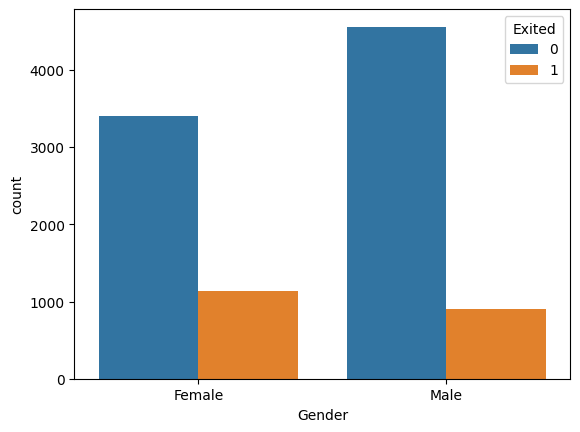

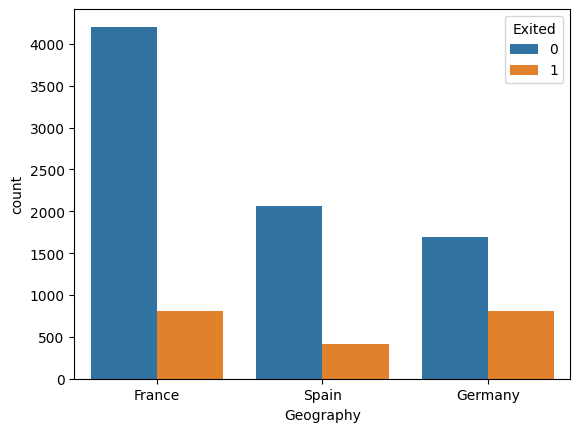

In [6]:
new_telco = data[["Gender", "Geography"]]
for i, j in enumerate(new_telco):
    plt.figure()
    sns.countplot(data = new_telco, x = j, hue = data["Exited"])
    plt.show()

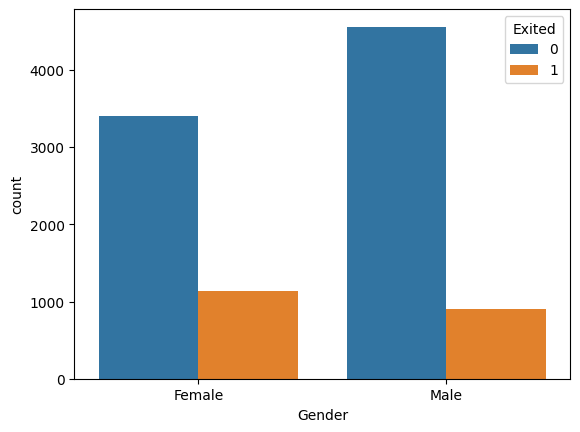

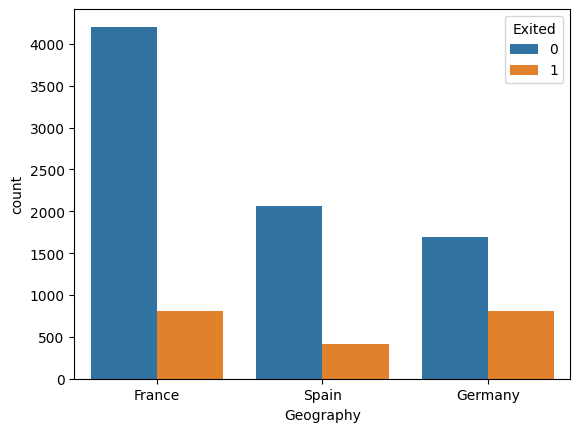

In [9]:
# Count Plot Graph
new_telco = data[["Gender", "Geography"]]
for i, j in enumerate(new_telco):
    plt.figure()
    sns.countplot(data = new_telco, x = j, hue = telco_new["Exited"])
    
# Same
# for i, j in enumerate(telco_new.drop(columns = ["Exited"])):
#     plt.figure()
#     sns.countplot(data = telco_new, x = j, hue = "Exited")

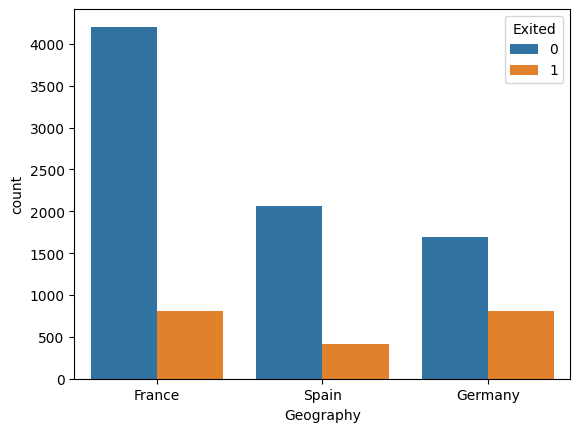

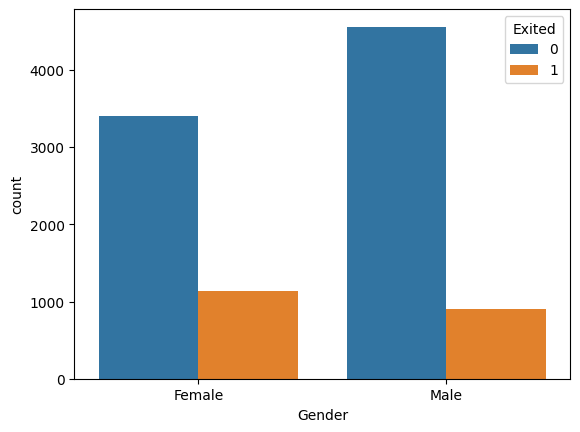

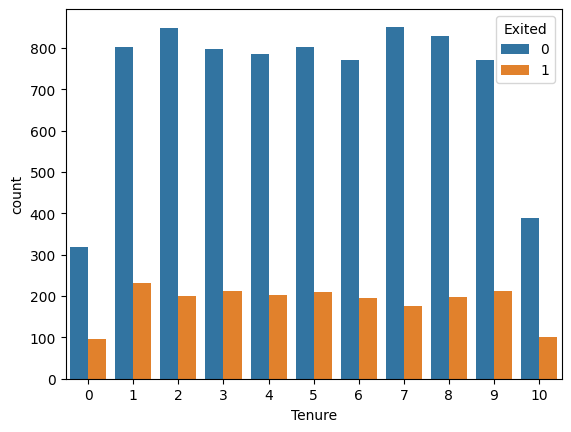

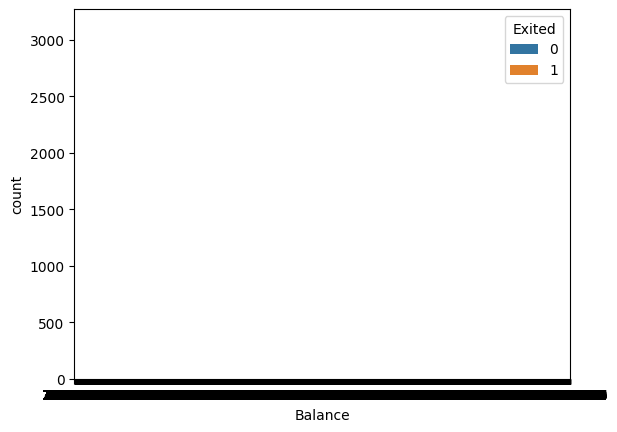

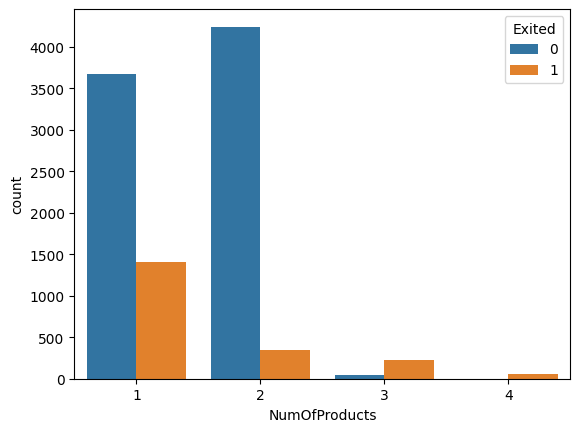

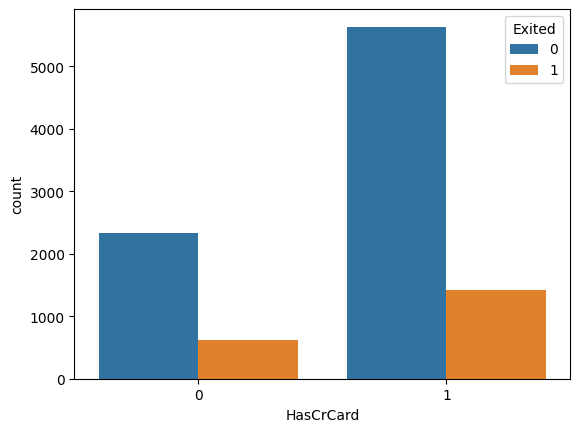

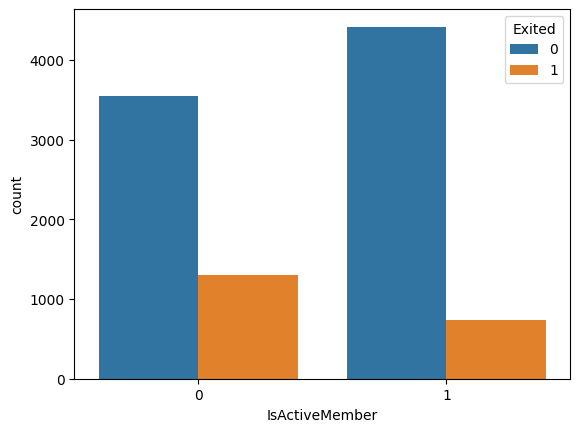

In [10]:
for i, j in enumerate(data.drop(columns = ["Exited", "RowNumber", "CustomerId", "Surname", "EstimatedSalary", "CreditScore", "Age"])):
    plt.figure()
    sns.countplot(data = data, x = j, hue = data["Exited"]) 

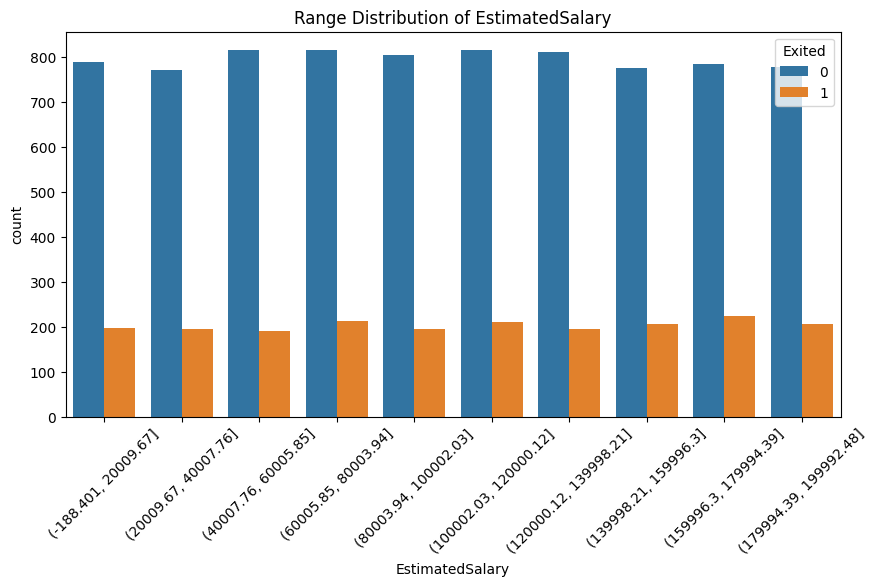

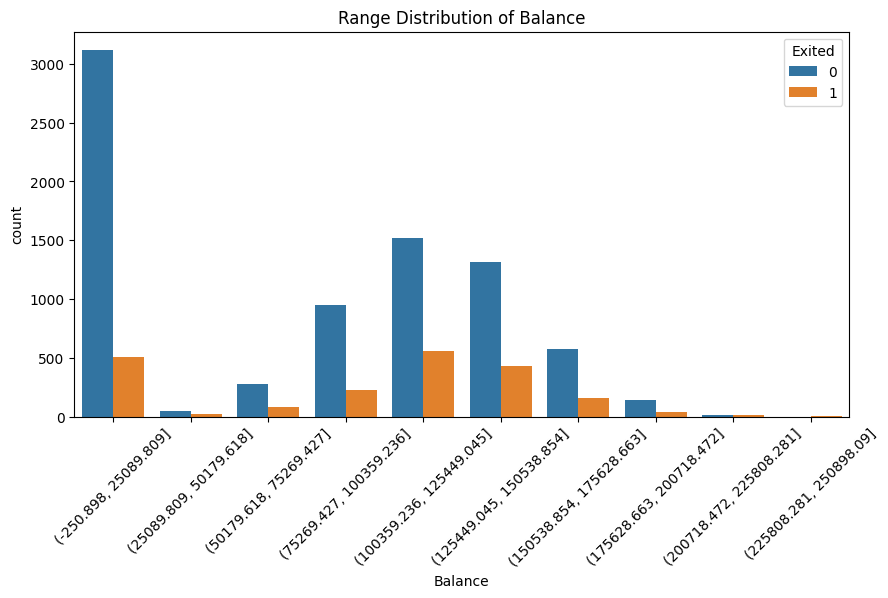

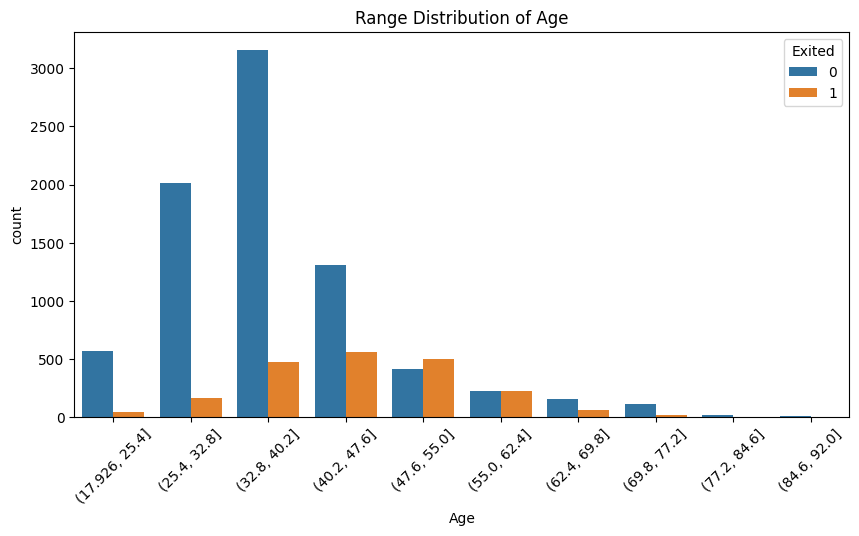

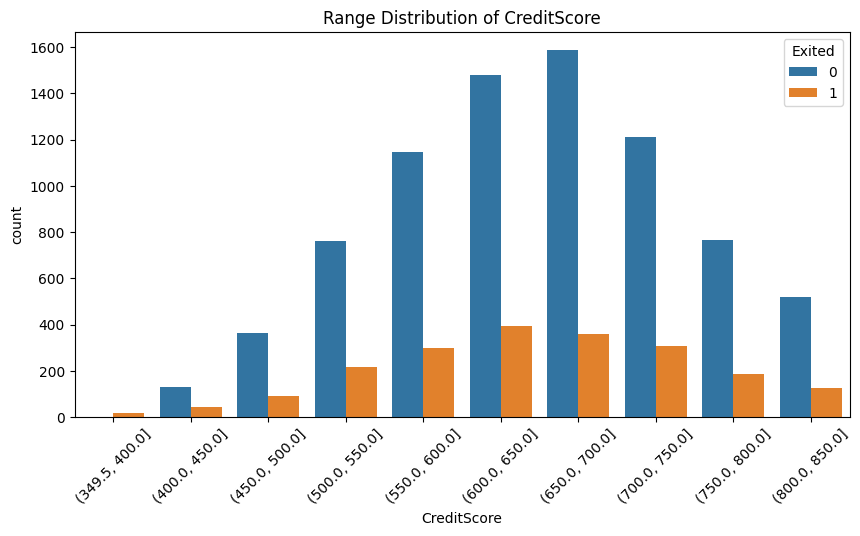

In [11]:
# 1. Define the columns you want to plot
my_nums = ["EstimatedSalary", "Balance", "Age", "CreditScore"]

for col in my_nums:
    plt.figure(figsize=(10, 5))
    
    # 2. Create a temporary 'Range' column with 10 equal bins
    # This creates labels like "(20, 30]" which represent the range
    temp_range = pd.cut(data[col], bins=10)
    
    # 3. Use countplot to show these text-based ranges clearly
    sns.countplot(x=temp_range, hue=data["Exited"])
    
    # 4. Rotate the labels so they don't overlap
    plt.xticks(rotation=45)
    plt.title(f"Range Distribution of {col}")
    plt.show()